In [3]:
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

These steps were followed:
1. State the Null and the Alternative Hypotheses.
2. Define your alpha.
3. Collect data that is random and independent
4. Calculate the test result
5. Interpret the test result

Hypothesis testing: Chi-Square Test within the Eniac case study
In this notebook we perform a chi-square test with the data from the Eniac case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

# 1.&nbsp;State the Null Hypothesis and the Alternative Hypothesis.

Null Hypothesis H0: All versions have the same CTR.

Alternative Hypothesis HA: There is a difference in the CTR for the different versions.

# 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

It was decided that a relatively high alpha was acceptable in this case

In [8]:
alpha = 0.05

# 3.&nbsp; Collect data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 

In [4]:
# Load A/B testing variants using clean relative paths
sample_a = pd.read_csv("../data/eniac_a.csv")
sample_b = pd.read_csv("../data/eniac_b.csv")
sample_c = pd.read_csv("../data/eniac_c.csv")
sample_d = pd.read_csv("../data/eniac_d.csv")

In [10]:
pd.set_option('display.max_colwidth', None)

Clicks are stored in row Shop NOw/SeeDeals (column Name), extract number of clicks from column No.Clicks

In [12]:
a_clicks = sample_a.loc[sample_a['Name'] == 'SHOP NOW', 'No. clicks'].values[0]

In [13]:
# using a for loop to get click of a 4 samples at once
clicks=[]
versions=['SHOP NOW','SEE DEALS']
for df in [sample_a, sample_b, sample_c, sample_d]:
    clicks_1 = df.loc[df['Name'] .isin(versions), 'No. clicks'].iloc[0]
    clicks.append(clicks_1)
clicks

[np.int64(512), np.int64(281), np.int64(527), np.int64(193)]

In [14]:
#Number of visits
sample_a.loc[1, 'Snapshot information']

'created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks'

In [15]:
# automatically using regex, manually if completly fine, too!
visits = []
for df in (sample_a, sample_b, sample_c, sample_d):
  # Extracts the numeric count from a string containing one or more digits followed by the word "visits."
    val = df.loc[df['Name'] == 'mySidebar', 'Snapshot information'].str.extract(r'(\d+)\s+visits')[0]
    visits.append(int(val.item()))

visits

[25326, 24747, 24876, 25233]

In [16]:
#set up dataFrame/contengency table
observed_results = pd.DataFrame(
    [clicks, visits], columns=["A", "B", "C","D"], index=["Clicks", "Visits"]
)
observed_results.loc['No_clicks'] = observed_results.loc['Visits'] - observed_results.loc['Clicks']
observed_results

,A,B,C,D
Clicks,512,281,527,193
Visits,25326,24747,24876,25233
No_clicks,24814,24466,24349,25040


In [17]:
data = observed_results.loc[['Clicks', 'No_clicks']]
data

,A,B,C,D
Clicks,512,281,527,193
No_clicks,24814,24466,24349,25040


4. # Calculate the test result

In [18]:
chisq, pvalue, df, expected = stats.chi2_contingency(data)

In [19]:
chisq

np.float64(224.01877488058412)

In [20]:
pvalue

np.float64(2.716121660786871e-48)

## 5.&nbsp; Interpret the test result

The p-value is smaller than alpha.
  We reject the null hypothesis. There is a sufficient evidence to suggest
  at least one of the web pages has a significantly different click through rate
  compared to the others. Identify the better performing website with post-hoc test.

# How do we decide who's the winner?

In [21]:
import itertools

combos = list(itertools.combinations(data, 2))

for combo in combos:
  print(f"{combo[0]} vs {combo[1]}", end=': ')
  res = stats.chi2_contingency(data.loc[:,list(combo)])
  if res.pvalue < alpha / len(combos):
    print(f"Significant. p = {res.pvalue:.3f}")
  else:
    print(f"NOT significant. p = {res.pvalue:.3f}")


A vs B: Significant. p = 0.000
A vs C: NOT significant. p = 0.465
A vs D: Significant. p = 0.000
B vs C: Significant. p = 0.000
B vs D: Significant. p = 0.000
C vs D: Significant. p = 0.000


Calculate and plot CTRs

In [22]:
# CTR rate
observed_results.loc['CTR'] = observed_results.loc['Clicks'] / observed_results.loc['Visits']
observed_results.loc['CTR'].sort_values(ascending=False)
observed_results

,A,B,C,D
Clicks,512.000000,281.000000,527.000000,193.000000
Visits,25326.000000,24747.000000,24876.000000,25233.000000
No_clicks,24814.000000,24466.000000,24349.000000,25040.000000
CTR,0.020216,0.011355,0.021185,0.007649


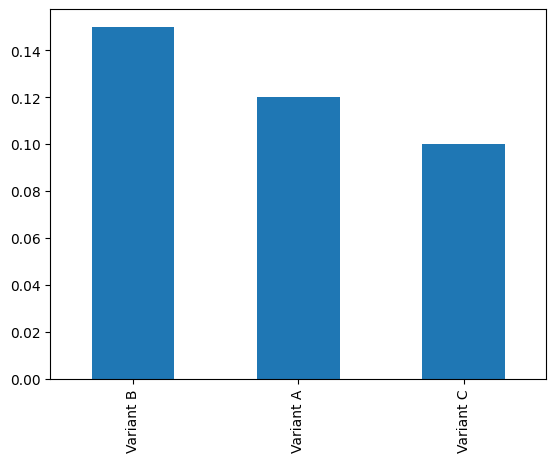

In [26]:
observed_results.loc['CTR'].sort_values(ascending=False).plot(kind='bar');

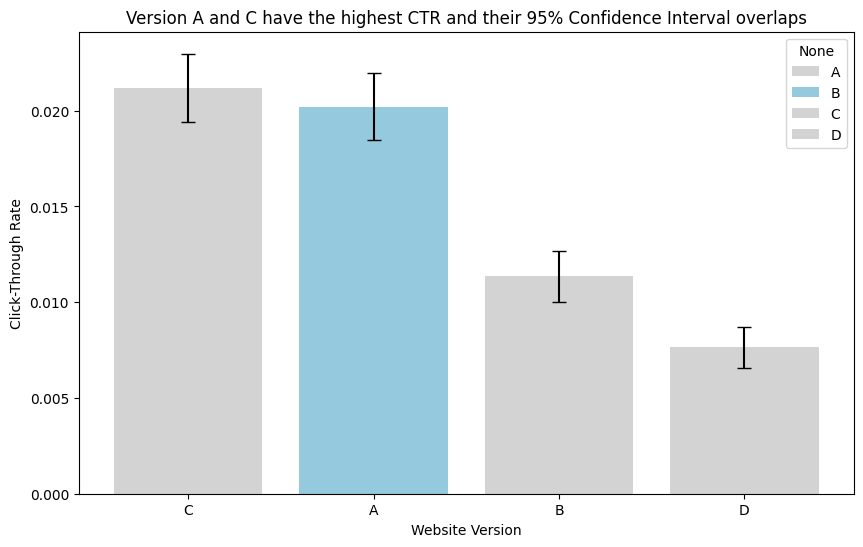

In [24]:
# 1. Calculate Standard Error and Margin of Error (95% CI)
# Formula: 1.96 * sqrt( (p * (1-p)) / n )
z = 1.96
observed_results_T = observed_results.T  # Transpose so versions are rows
p = observed_results_T['CTR']
n = observed_results_T['Visits']

moe = z * np.sqrt((p * (1 - p)) / n)

# 2. Plotting
plt.figure(figsize=(10, 6))
order = p.sort_values(ascending=False).index

ax = sns.barplot(
    x=order,
    y=p.loc[order],
    hue=observed_results_T.index,
    palette=['skyblue' if webp == 'A' else 'lightgrey' for webp in order]
)

# 3. Add the manual error bars
plt.errorbar(
    x=np.arange(len(order)),
    y=p.loc[order],
    yerr=moe.loc[order],
    fmt='none', c='black', capsize=5
)

plt.title('Version A and C have the highest CTR and their 95% Confidence Interval overlaps')
plt.ylabel('Click-Through Rate')
plt.xlabel('Website Version')
plt.show()

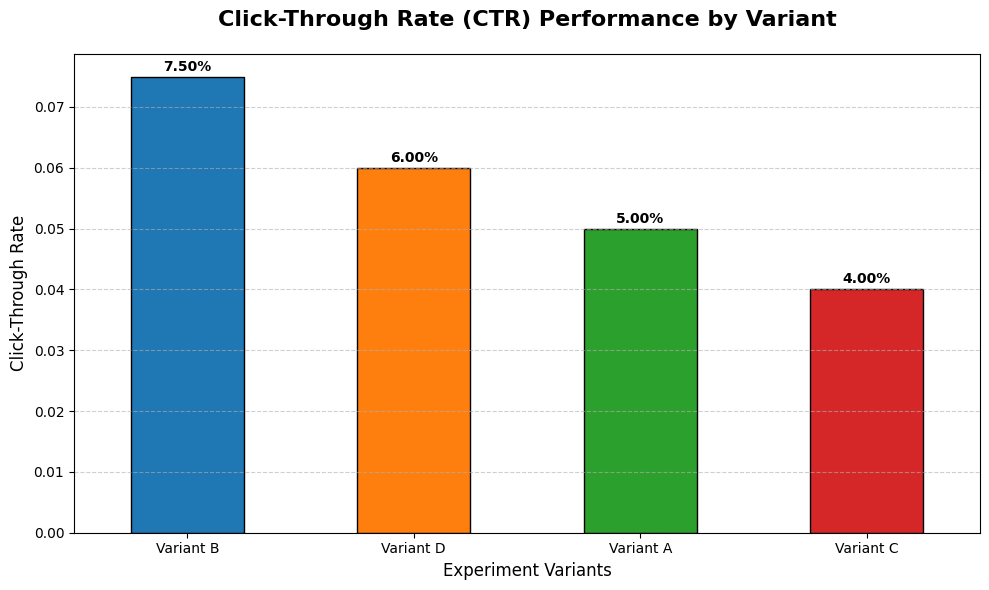

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating dummy data for four variants to match the user's specific request
data = {
    'Variant A': [1000, 50, 0.05],
    'Variant B': [1000, 75, 0.075],
    'Variant C': [1000, 40, 0.04],
    'Variant D': [1000, 60, 0.06]
}
observed_results = pd.DataFrame(data, index=['Impressions', 'Clicks', 'CTR'])

# Plotting the four variants
ctr_data = observed_results.loc['CTR'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = ctr_data.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black')

plt.title('Click-Through Rate (CTR) Performance by Variant', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Click-Through Rate', fontsize=12)
plt.xlabel('Experiment Variants', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding value labels on top of bars
for i, v in enumerate(ctr_data):
    ax.text(i, v + 0.001, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()